<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/Entrega_6/Clasificacion_de_celulas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Paso 1: Subir archivo desde tu computadora
from google.colab import files
uploaded = files.upload()

Saving BaseDatos_CelulasSangre_Train.zip to BaseDatos_CelulasSangre_Train.zip
Saving BaseDatos_CelulasSangre_Test.zip to BaseDatos_CelulasSangre_Test.zip


#***SECCIÓN 1: EXTRACCIÓN DE CARACTERÍSTICAS, EDA y PCA***


#Carga de datos

In [16]:
def cargar_dataset_y_features(ruta_base, dicc_clases):
    X = []
    y = []
    paths = []

    for carpeta, etiqueta in dicc_clases.items():
        carpeta_path = os.path.join(ruta_base, carpeta)

        for archivo in os.listdir(carpeta_path):
            img_path = os.path.join(carpeta_path, archivo)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (128,128))

            # Extraer 3 características
            ent, cont, dens_b = extraer_caracteristicas(img)

            X.append([ent, cont, dens_b])
            y.append(etiqueta)
            paths.append(img_path)

    return np.array(X), np.array(y), paths


#Extraccion de caracteristicas

In [17]:
import os
import cv2
import numpy as np
from skimage.measure import shannon_entropy
from skimage.feature import graycomatrix, graycoprops

def extraer_caracteristicas(img):
    """
    Extrae 3 características de textura:
    1. Entropía
    2. Contraste (GLCM)
    3. Densidad de bordes (Canny)
    """

    # 1. ENTROPÍA
    entropia = shannon_entropy(img)

    # 2. CONTRASTE GLCM
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256,
                        symmetric=True, normed=True)
    contraste = graycoprops(glcm, 'contrast')[0][0]

    # 3. DENSIDAD DE BORDES
    edges = cv2.Canny(img, 100, 200)
    dens_bordes = np.mean(edges > 0)

    return entropia, contraste, dens_bordes


In [ ]:

!ls celulas_descomprimidas/Inference


Basofilos_inference  Eritoblastos_inference


In [15]:
import zipfile
import os

# Define the path for the unzipped files
unzip_path = "celulas_descomprimidas"

# Create the directory if it doesn't exist
if not os.path.exists(unzip_path):
    os.makedirs(unzip_path)

# Unzip the training data if not already unzipped
zip_file_path_train = "BaseDatos_CelulasSangre_Train.zip"
if os.path.exists(zip_file_path_train):
    with zipfile.ZipFile(zip_file_path_train, 'r') as zip_ref:
        zip_ref.extractall(unzip_path)
    print(f"'{zip_file_path_train}' unzipped to '{unzip_path}'")
else:
    print(f"Warning: '{zip_file_path_train}' not found. Ensure it's uploaded.")

# Unzip the test data if not already unzipped
zip_file_path_test = "BaseDatos_CelulasSangre_Test.zip"
if os.path.exists(zip_file_path_test):
    with zipfile.ZipFile(zip_file_path_test, 'r') as zip_ref:
        zip_ref.extractall(unzip_path)
    print(f"'{zip_file_path_test}' unzipped to '{unzip_path}'")
else:
    print(f"Warning: '{zip_file_path_test}' not found. Ensure it's uploaded.")

clases_train = {
    "Basofilos_train": 0,
    "Eritroblasto_train": 1
}

X_train, y_train, paths_train = cargar_dataset_y_features(unzip_path, clases_train)

print(X_train.shape)
print(y_train.shape)


clases_test = {
    "Basofilos_inference": 0,
    "Eritoblastos_inference": 1
}

X_test, y_test, paths_test = cargar_dataset_y_features(os.path.join(unzip_path, "Inference"), clases_test)

print(X_test.shape)
print(y_test.shape)

'BaseDatos_CelulasSangre_Train.zip' unzipped to 'celulas_descomprimidas'
'BaseDatos_CelulasSangre_Test.zip' unzipped to 'celulas_descomprimidas'
(120, 3)
(120,)
(10, 3)
(10,)


In [25]:
import pandas as pd

celulas = pd.DataFrame({
    "entropia": X_train[:,0],
    "contraste": X_train[:,1],
    "densidad_bordes": X_train[:,2],
    "clase": y_train
})



In [26]:
celulas.shape

(120, 4)

In [20]:
#Exportar CSV

celulas.to_csv("dataset_120x4_train.csv", index=False)


#EDA

In [24]:
import pandas as pd

celulas= pd.read_csv("dataset_120x4_train.csv")
celulas.head()


,entropia,contraste,densidad_bordes,clase
0,5.759945,176.721088,0.107971,0
1,5.561098,146.241265,0.075928,0
2,5.769350,139.358883,0.085632,0
3,5.930780,239.089505,0.133911,0
4,5.652235,195.638841,0.092468,0


<Axes: title={'center': 'Distribución de clases'}, xlabel='clase'>

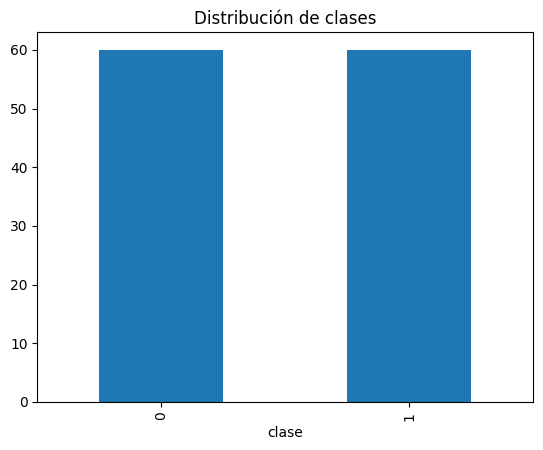

In [28]:
celulas["clase"].value_counts().plot(kind="bar", title="Distribución de clases")


In [30]:
celulas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   entropia         120 non-null    float64
 1   contraste        120 non-null    float64
 2   densidad_bordes  120 non-null    float64
 3   clase            120 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 3.9 KB


In [31]:
celulas.describe()


,entropia,contraste,densidad_bordes,clase
count,120.000000,120.000000,120.000000,120.000000
mean,5.501136,123.333297,0.075287,0.500000
std,0.470321,76.023334,0.032570,0.502096
min,4.166434,32.933317,0.010437,0.000000
25%,5.180659,55.729654,0.057190,0.000000
50%,5.624037,92.209400,0.082886,0.500000
75%,5.824610,187.102162,0.097214,1.000000
max,6.419426,331.744218,0.134460,1.000000


In [32]:
#Estadisticos descriptivos por cada clase

celulas.groupby("clase")[["entropia","contraste","densidad_bordes"]].mean()



,entropia,contraste,densidad_bordes
clase,,,
0,5.727595,191.270986,0.098323
1,5.274676,55.395608,0.052251


Histogramas por variables

Text(0.5, 1.0, 'Distribución de Entropía')

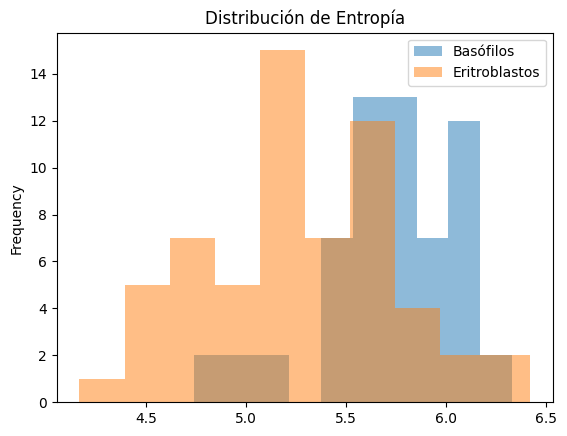

In [34]:
#Entropia
celulas[celulas["clase"]==0]["entropia"].plot(kind="hist", alpha=0.5, label="Basófilos")
celulas[celulas["clase"]==1]["entropia"].plot(kind="hist", alpha=0.5, label="Eritroblastos")
plt.legend(); plt.title("Distribución de Entropía")


Text(0.5, 1.0, 'Distribución de Contraste')

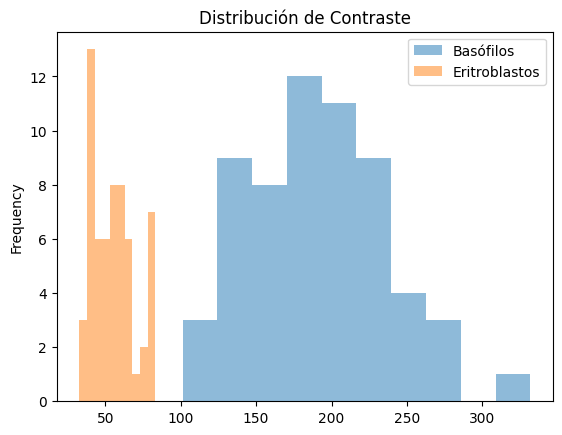

In [35]:
#Contraste

celulas[celulas["clase"]==0]["contraste"].plot(kind="hist", alpha=0.5, label="Basófilos")
celulas[celulas["clase"]==1]["contraste"].plot(kind="hist", alpha=0.5, label="Eritroblastos")
plt.legend(); plt.title("Distribución de Contraste")


Text(0.5, 1.0, 'Distribución de Densidad de Bordes')

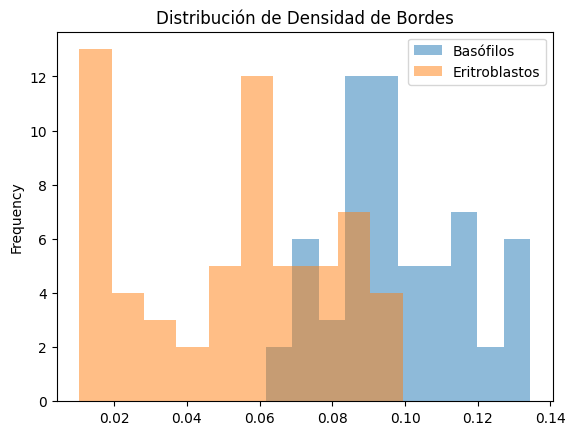

In [38]:
#Densidad de bordes

celulas[celulas["clase"]==0]["densidad_bordes"].plot(kind="hist", alpha=0.5, label="Basófilos")
celulas[celulas["clase"]==1]["densidad_bordes"].plot(kind="hist", alpha=0.5, label="Eritroblastos")
plt.legend(); plt.title("Distribución de Densidad de Bordes")


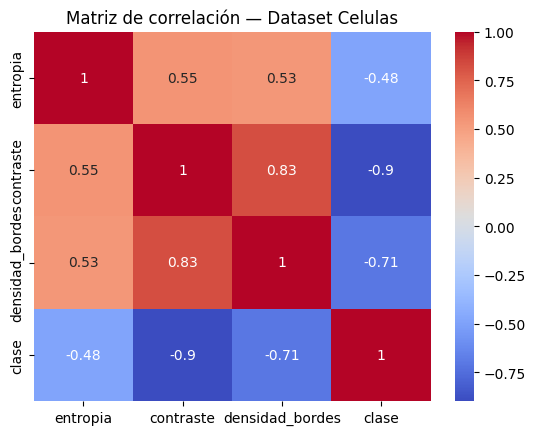

In [39]:
#Matriz de correlacion
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(celulas.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación — Dataset Celulas")
plt.show()


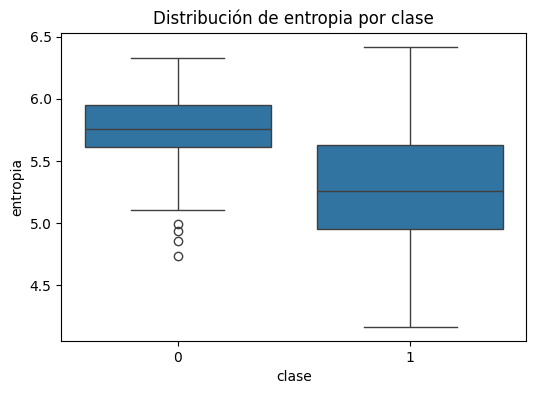

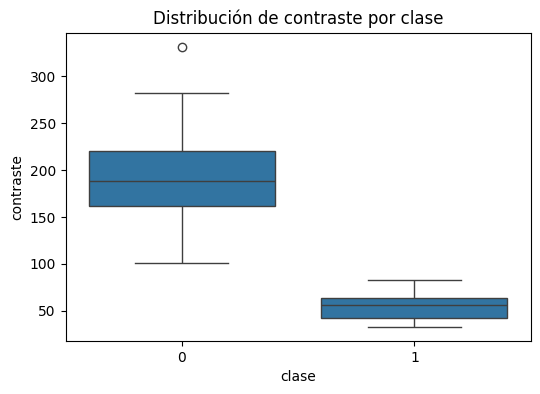

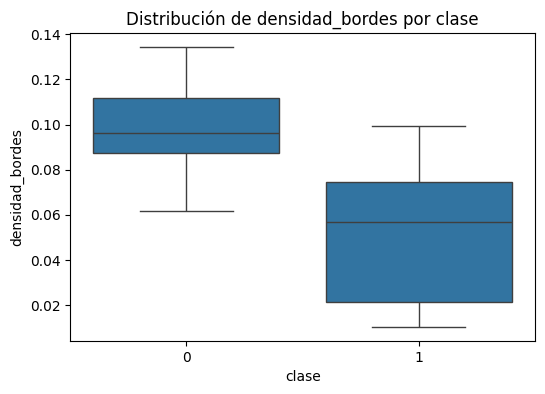

In [40]:
for v in ["entropia","contraste","densidad_bordes"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="clase", y=v, data=celulas)
    plt.title(f"Distribución de {v} por clase")
    plt.show()


#PCA



In [41]:
import pandas as pd

# Ya tienes cargado:
# celulas = pd.read_csv("dataset_120x4_train.csv")

X = celulas[["entropia", "contraste", "densidad_bordes"]]
y = celulas["clase"]


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#***SECCIÓN 2: CLASIFICACIÓN UTILIZANDO APRENDIZAJE SUPERVISADO***
